# **🚆 Metro Interstate Traffic Volume Prediction Assignment**

Welcome to this assignment, built around the **Metro_Interstate_Traffic_Volume** dataset, which provides data about train traffic in the USA. The dataset includes several features:

### **Features**
- **Temperature** 🌡️  
- **Rain** 🌧️  
- **Holidays** 🎉  
- **Date and Time** 📅  
- **Traffic Volume** 🚦  

---

### **Objective**
Your goal is to predict the **Traffic Volume**, representing the number of passengers on a given day. Imagine an app that helps users determine whether the train station will be crowded or not. In this context, **Traffic Volume** serves as our target label.

---

### **Instructions**
To achieve this goal, follow the steps and hints provided in this notebook. Your final objective is to:
1. **Achieve higher accuracy than your peers!**  
2. Use **two approaches**:
   - A **Classical Technique** (e.g., Linear Regression, Random Forest, etc.)  
   - A **Neural Network**

---

### **Deliverables**
- Report the best results achieved using the classical technique and the neural network.  
- Feel free to preprocess the data as needed. This notebook provides ideas and hints for data preprocessing.

---

💡 **Pro Tip**: Experiment, be creative, and aim for high performance while learning!


**General Imports**

In [1]:

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

**Loading Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume (1).csv


In [3]:
import pandas as pd
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

**Use display to have a look on the dataset**

In [4]:
display(df.head())

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


**The dataset does not include Saturdays and Sundays, which are considered weekend days in the United States.**

**Try to add a column to indicate whether a given day is a weekend or not.
Note that the dataset uses two formats for recording dates, for example:**

* 16-10-2012 07:00
* 2/10/2012 9:00:00 AM

In [5]:
df['date'] = pd.to_datetime(df['date_time'], errors='coerce', dayfirst=True)
# pd.to_dateeime() => convert any date format to datetime format
# errors => convert not clear date to NaT (null dates)
# dayfirst => Consider the first number the day, not the month (MM/DD/YYYY)



In [6]:
print(df['date'].head(5))

0   2012-02-10 09:00:00
1   2012-02-10 10:00:00
2   2012-02-10 11:00:00
3   2012-02-10 12:00:00
4   2012-02-10 13:00:00
Name: date, dtype: datetime64[ns]


In [7]:
# dt.weekday() to get the day of the week (0:Monday=>6:Sunday)
# add column is_weekend
df['is_weekend'] = df['date'].dt.weekday >= 5
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,date,is_weekend
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,2012-02-10 09:00:00,False
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,2012-02-10 10:00:00,False
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2012-02-10 11:00:00,False
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,2012-02-10 12:00:00,False
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,2012-02-10 13:00:00,False


**Now we want to visualise the data looking for trends and correlations**


**this function may help you visualizing categorical data**
**Note that you may not use it**



```
def cat_draw(number_of_plots, categorical_columns):
    num_columns = min(len(categorical_columns), number_of_plots)
    num_rows = (len(categorical_columns) + 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(16, 8*num_rows))```



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

 ⌚ **Traffic changes by the hour**

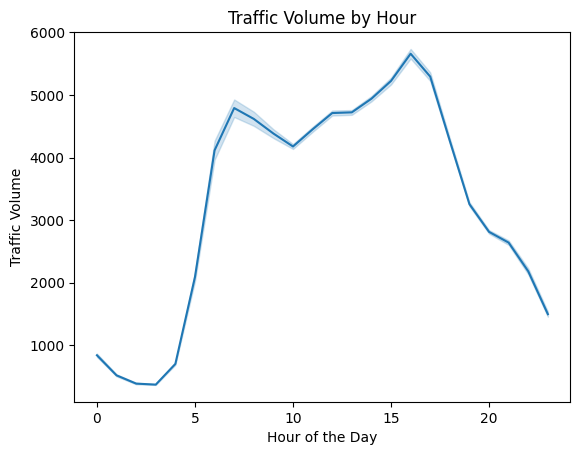

In [9]:
df['hour'] = df['date'].dt.hour
sns.lineplot(x='hour', y='traffic_volume', data=df)
plt.title('Traffic Volume by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Traffic Volume')
plt.show()

Traffic volume throughout the day :

I noticed that traffic gradually increases starting from the early morning hours and reaches its peak between 3 and 4 pm, then begins to decrease until the end of the day

🌦️ **Weather impact on traffic**

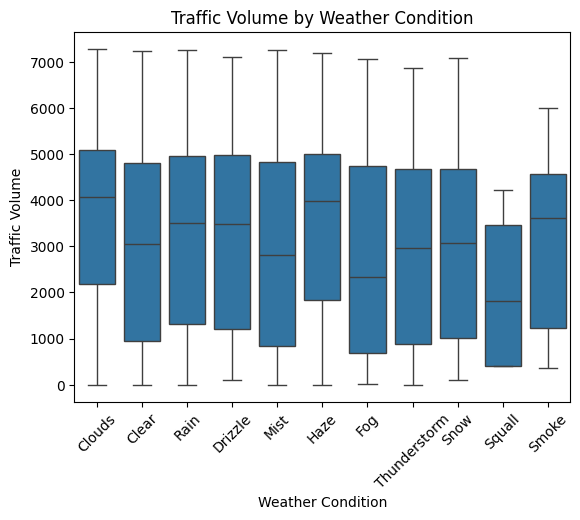

In [10]:
sns.boxplot(x='weather_main', y='traffic_volume', data=df)
plt.title('Traffic Volume by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45)
plt.show()

Weather impact on traffic :

I can see that traffic volume varies depending on the weather conditions, as it may be higher in clear skies and lower in severe conditions such as snowstorms or heavy fog and Squall

🍹🥳 **Is traffic less during holidays ?**

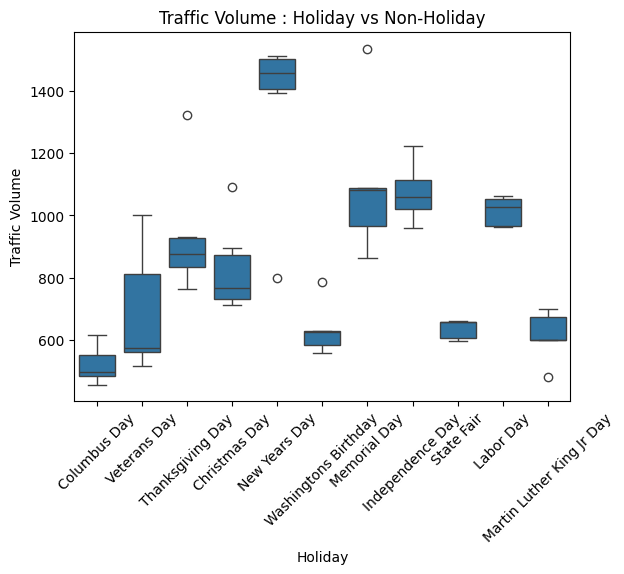

In [11]:
sns.boxplot(x='holiday', y='traffic_volume', data=df)
plt.title('Traffic Volume : Holiday vs Non-Holiday')
plt.xlabel('Holiday')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45)
plt.show()

Is traffic less during holidays ?

 Some holidays experience a decrease in traffic volume, while others experience an increase

🏃🏻‍♀️ 🧘‍♀️ **Is there a difference between weekday and weekend ?**

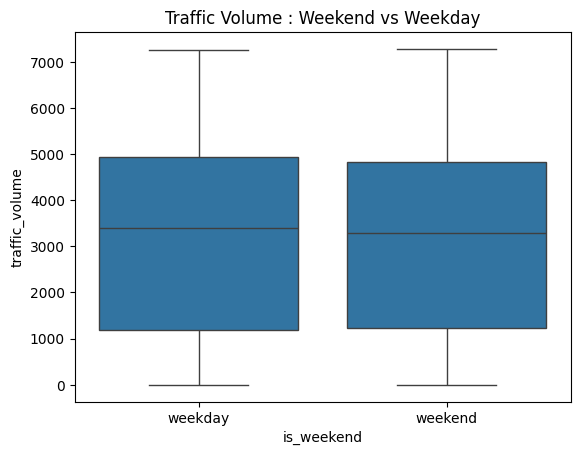

In [12]:
sns.boxplot(x='is_weekend', y='traffic_volume', data=df)
plt.title('Traffic Volume : Weekend vs Weekday')
plt.xticks([0,1],['weekday', 'weekend'])
plt.show()

No significant difference, weekend traffic is not necessarily less or more congested than weekdays, which may mean a more even distribution of daily trips



---



---


**Now visualize numerical data**

* traffic_volume
* temp
* clouds_all

**I photograph the numerical data to understand its distribution, the relationships between them, and whether there are outliers or specific trends**

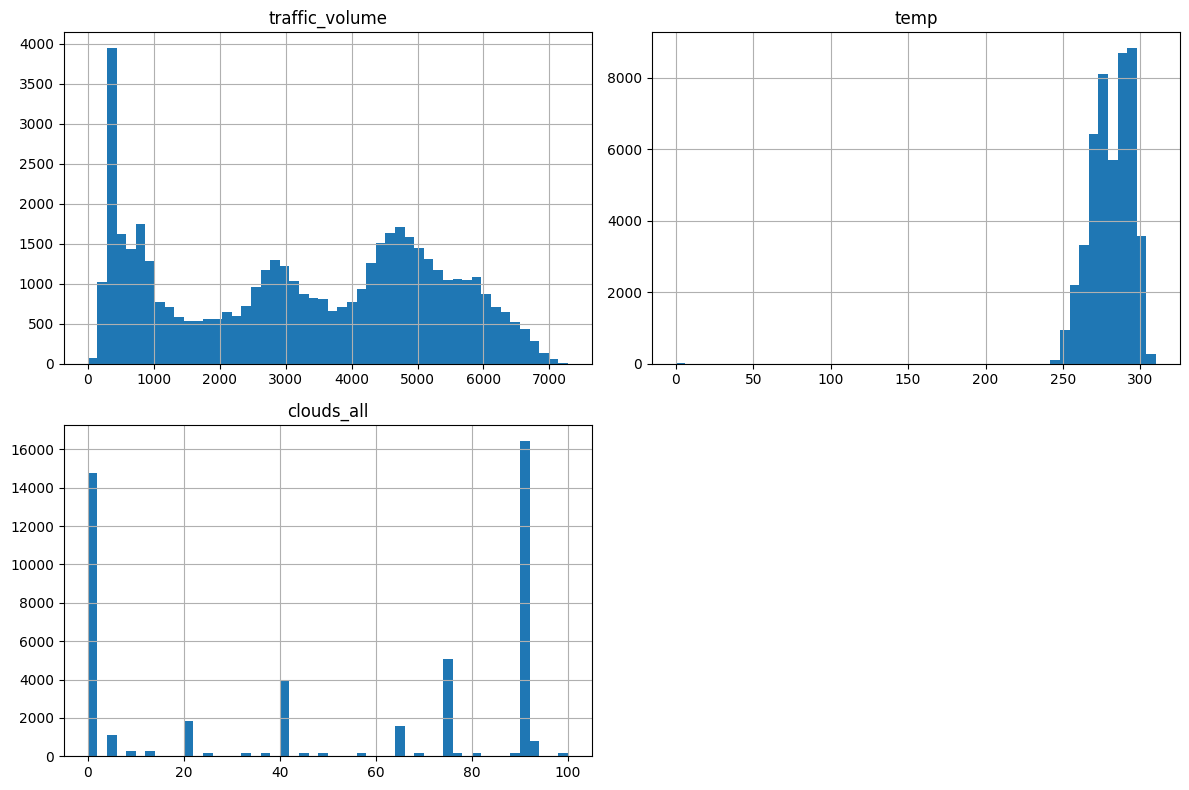

In [13]:
# Histogram : Distribution graph
numerical_columns = ['traffic_volume', 'temp', 'clouds_all']
df[numerical_columns].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()


**Histogram for traffic_volume**

X-axis: represents traffic volume values

Y-axis: How many times (how many hours) has this amount of traffic occurred?

The histogram shows how traffic volumes are distributed, with peaks at values ​​such as 0, 3000, and 5000
.............................................................................................................................................................................................................................................
**Histogram for temp** (( Kelvin temperature ))

X-axis: Temperature

Y-axis: How many hours were the temperatures at that temperature

The histogram shows that most temperatures fall between 250 and 300 (❄️-23°C and 🌞27°C.)

.............................................................................................................................................................................................................................................
**Histogram for clouds_all**

This column represents the amount of cloudiness as a percentage (0 = clear, 100 = completely cloudy)

X-axis: Cloudiness (from 0 to 100)

Y-axis: How many hours (or times) did this percentage occur


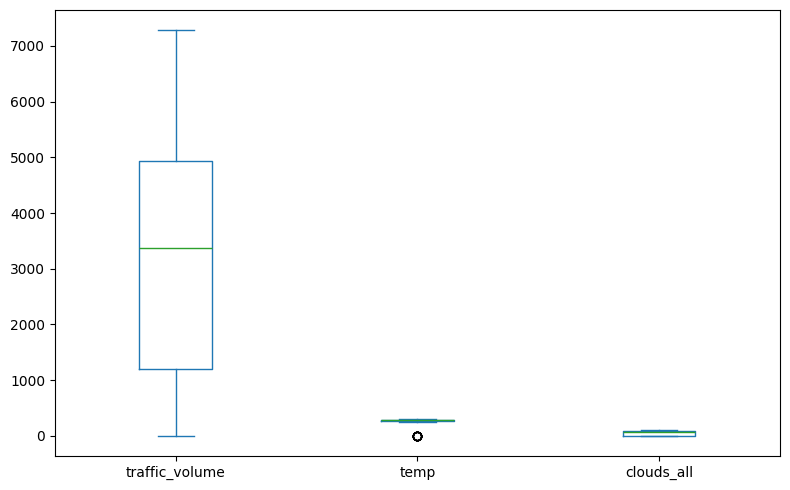

In [14]:
# Boxplot : to detect outliers and spread
df[numerical_columns].plot(kind='box', figsize=(8, 5))
plt.tight_layout()
plt.show()


The graphs generated by a boxplot show how the data is distributed and detect outliers

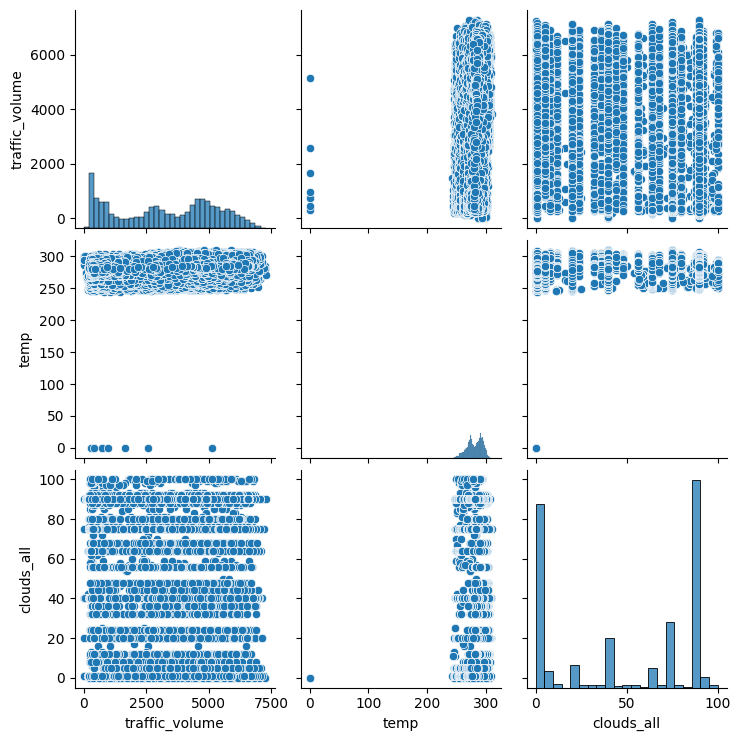

In [15]:
# Pairplot (to show the relationships between them)
sns.pairplot(df[numerical_columns])
plt.show()



---



---


**Now we must encode and scale the data, to make your code clean try to use pipelines**

**Encode and Scale Using Pipeline**

Prepare data using Pipeline to make it ready for models (classical or neural networks)

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer



# Read data
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

target = "traffic_volume"
X = df.drop(columns=[target]) # Dataset X, which contains all the original columns except the target column.
y = df[target] # Dataset y, which contains only the values ​​in traffic_volume column
# y : This set is the target variable that the model seeks to predict based on the data in X.


# === Date Feature Engineering ===
if 'date_time' in X.columns:
    X['date_time'] = pd.to_datetime(X['date_time'])
    X['hour'] = X['date_time'].dt.hour
    X['dayofweek'] = X['date_time'].dt.dayofweek
    X['month'] = X['date_time'].dt.month
    X['is_weekend'] = X['dayofweek'].isin([5, 6]).astype(int)
    X = X.drop(columns=['date_time'])


# Define numeric and categorical columns
categorical = ['weather_main', 'weather_description', 'is_weekend']
numerical = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'dayofweek', 'month']



# Pipeline: Encoding + Scaling
# Preparing pipeline for pretreatment (Create a preprocessor using ColumnTransformer)
# OneHotEncoder: Used to convert text variables (such as columns containing categorical values) into a numeric representation
# StandardScaler: Used to standardize numerical values ​​by transforming them into a distribution with a mean=0 and a standard deviation=1
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical), # Convert texts into numbers
    ('num', StandardScaler(), numerical) # Standardization of numerical values

])





**Search for correlations**

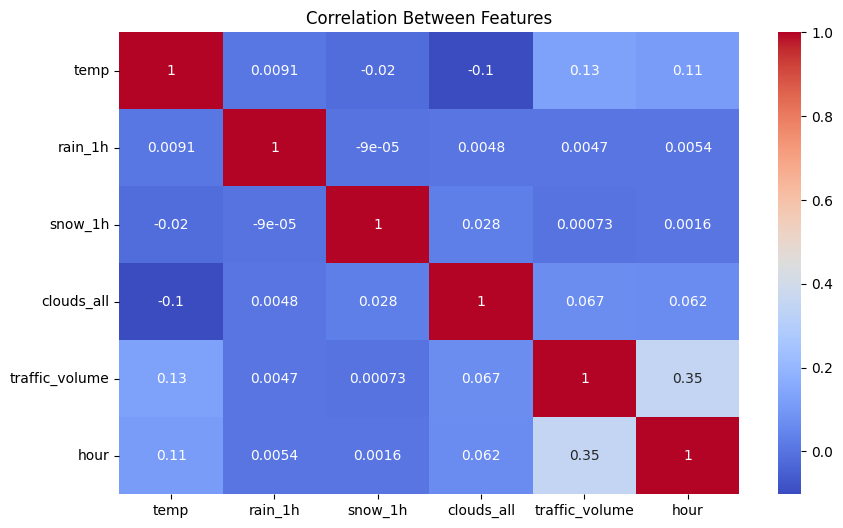

In [17]:
# Correlation analysis between variables
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Features')
plt.show()

heatmap illustrating the correlation relationships between the numerical variables in the dataset.

The different colors in the heatmap represent the strength and direction of the relationship between each pair of variables, based on the correlation coefficient, which ranges from -1 to +1:

Red colors:

Indicate a strong positive correlation. The deeper the red, the stronger the correlation, meaning that an increase in one variable is associated with an increase in the other.

Blue colors:

Indicate a negative correlation, meaning that an increase in one variable is associated with a decrease in the other. The darker the blue, the stronger the negative correlation.

light colors ( white or light gray):

Suggest weak or no correlation between the variables, where the correlation coefficient is close to zero

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
The numbers shown within the heatmap represent the actual correlation coefficient values between each pair of variables, where:

A value of +1 indicates a perfect positive correlation.

A value of -1 indicates a perfect negative correlation.

A value of 0 indicates no correlation.



**We have to split the data to train and test sets before training on any model**


* **You must use this code to split the data**
```
train_test_split(X, y, test_size=0.2, random_state=42)
```



In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Classical technique model**
* **Use mean_absolute_error as a metric**

In [36]:
# Classic Model: Linear Regression + MAE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Building the pipeline for the classical model
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Training the Model
linear_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['weather_main',
                                                   'weather_description',
                                                   'is_weekend']),
                                                 ('num', StandardScaler(),
                                                  ['temp', 'rain_1h', 'snow_1h',
                                                   'clouds_all', 'hour',
                                                   'dayofweek', 'month'])])),
                ('regressor', LinearRegression())])

In [37]:
# Forecasting and Measuring Performance Using MAE
# Prediction on test data
y_pred = linear_model.predict(X_test)
"""
It is the basic step of prediction after the model has been trained on the training data
linear_model: The model we trained using LinearRegression.
predict(X_test): This means "Apply the model to the test data, X_test, and try to predict the corresponding values."
y_pred: The output, which is the predicted values ​​for the target (y) on the test set.
==> Through it, we obtain the values ​​that the model "predicted."
We use y_pred to compare the predictions with the actual values ​​(y_test) and calculate the error (like MAE).
"""

# Evaluation : Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 1559.807852782935


**Neural Network model**
* **Use mean_absolute_error as a metric**

**Model Selection: Sequential API**

I chose to implement the neural network using Keras Sequential API
This is because this regression problem is simple and doesn't require complex model architectures

The **Sequential model** is simple and effective for stacking layers in a linear fashion, which is suitable for this case

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_error

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Build the Model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_transformed.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Model Compile
model.compile(optimizer='adam', loss='mae')

# Training
model.fit(X_train_transformed, y_train, epochs=50, batch_size=32, verbose=1)

# Prediction
y_pred_nn = model.predict(X_test_transformed).flatten()

# Evaluation : Calculate MAE
mae_nn = mean_absolute_error(y_test, y_pred_nn)
print(f"Neural Network (Sequential) - Mean Absolute Error: {mae_nn:.2f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2639.5381
Epoch 2/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1543.9829
Epoch 3/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1536.7108
Epoch 4/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1507.3629
Epoch 5/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1427.7738
Epoch 6/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1202.3575
Epoch 7/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 906.1092
Epoch 8/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 764.4930
Epoch 9/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 700.9226
Epoch 10/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 639.8530
Epoch 11/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 585.7498
Epoch 12/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 528.2571
Epoch 13/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 500.1850
Epoch 14/50
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 475.



---



---


**Model Comparison:**

I implemented both a classic Linear Regression model and a Neural Network using the Sequential API
The Neural Network significantly outperformed the linear model, achieving a MAE of 331.62, compared to 1559.81 for the Linear Regression model

This shows that the neural network was better able to capture the complex patterns in the data, likely due to its capacity to model non-linear relationships.

